# Scenario 1

## Environment implementation

The environment implementation follows the specification of the assignment with a `Payoff Matrix`:

```python
self.payoff_matrix = [
    [(1, 2), (1, 1)],
    [(1,1), (2,1)]
]
```

The value-pairs in this list are the rewards for the `Y` and `X` agent types respectively.

We defined the graph of the agents as:

```python
self.graph = {
    "X1": ["Y1"],
    "X2": ["Y2"],
    "Y1": ["X1", "X3", "X4"],
    "Y2": ["X2", "X3", "X5"],
    "X3": ["Y1", "Y2", "X4", "X5"],
    "X4": ["Y1", "X3"],
    "X5": ["Y2", "X3"]
}
```

In each episode we iterate over each agent and accumulate actions and rewards. This implementation begs for optimization.

In [3]:
class environment1():
    def __init__(self):
        # [[(Row_Payoff, Col_Payoff), ...], ...]
        self.payoff_matrix = [
            [(1, 2), (1, 1)],
            [(1,1), (2,1)]
        ]

      # X (Column players) and Y (Row players)
        self.agent_types = {
            "X1": "X", "X2": "X", "X3": "X", "X4": "X", "X5": "X",
            "Y1": "Y", "Y2": "Y"
        }

        # Adjacency graph edges
        self.graph = {
            "X1": ["Y1"],
            "X2": ["Y2"],
            "Y1": ["X1", "X3", "X4"],
            "Y2": ["X2", "X3", "X5"],
            "X3": ["Y1", "Y2", "X4", "X5"],
            "X4": ["Y1", "X3"],
            "X5": ["Y2", "X3"]
        }

    def reset(self):
        pass

    def step(self, action_matrix):
        """
        Distributes rewards.
        action_matrix = {agent_name: agent_action}
        """

        rewards = {name: 0 for name in self.graph.keys()}

        # Traverse each agent in the graph
        for each_agent in self.graph.keys():
            # Traverse each opponents and calculate rewards
            for each_opponent in self.graph[each_agent]:
                # Extract actions
                act_agent = action_matrix[each_agent] - 1
                act_opp = action_matrix[each_opponent] - 1

                # Extract row column combo from payoff matrix
                if "Y" in each_agent:
                    row_idx, col_idx = act_agent, act_opp

                elif "Y" in each_opponent:
                    row_idx, col_idx = act_opp, act_agent

                else:
                    # Same pair of agents: X vs X
                    row_idx, col_idx = act_agent, act_opp

                # Extract payoff block
                payoff_block = self.payoff_matrix[row_idx][col_idx]

                if "Y" in each_agent:
                    rewards[each_agent] += payoff_block[0]
                else:
                    rewards[each_agent] += payoff_block[1]

        return rewards

## Agent implementation 

Here we implement a Q-learning algorithm with e-greedy exploration function.

The most critical part of the code for this scenario is the decoupling of the agent from the global state (opponent actions). Because agents have no vision of their neighbors, the Q-table is a simple mapping of action to value:

```python
self.q_table = {action: 0.0 for action in actions}
```

The learning process relies entirely on the $\epsilon$-greedy strategy, where $\epsilon$ decays by 0.01 every 40 episodes. This interval ensures that agents explore for exactly 4,000 episodes (40×100=4,000), or 4/5 of the total simulation time, as per the parameters of the assignment.

This period allows the agents to develop their Q-values and create their strategy against their neighbors. After 4000 iterations, we expect the agents to have convered into an optimal policy.

In [4]:
# Q-learning with e-greedy
import numpy as np

class QLearningAgent1():
    def __init__(self, agent_name, agent_type, actions=[1, 2], epsilon_init=1.0, epsilon_threshold=0.0, epsilon_decay=0.01, alpha=0.1, gamma=0.95):

        self.name = agent_name
        self.type = agent_type # "X" or "Y"
        self.action_space = actions

        # Q-table init - use dict to simplify action to index converesion
        self.q_table = {action: 0.0 for action in actions}

        # Hyperparams
        self.epsilon = epsilon_init
        self.epsilon_threshold = epsilon_threshold
        self.epsilon_decay = epsilon_decay
        self.alpha = alpha
        self.gamma = gamma

        # Metric tracking
        self.reward_history = []
        self.action_value_history = {1: [], 2: []}

    def action(self):
        if np.random.rand() < self.epsilon:
            chosen_action = np.random.choice(self.action_space)
        else:
            max_val = max(self.q_table.values())
            best_action = [a for a, v in self.q_table.items() if v == max_val]
            chosen_action = np.random.choice(best_action)

        return chosen_action

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_threshold:
            self.epsilon -= self.epsilon_decay

    def update_q_values(self, action, reward):
        # Standard Q-learning update: Q(a) = Q(a) + alpha * (reward + gamma * max(Q) - Q(a))
        max_next_q = max(self.q_table.values())
        self.q_table[action] += self.alpha * (reward + (self.gamma * max_next_q) - self.q_table[action])

## Simulation implementation

In [5]:
import matplotlib.pyplot as plt

def simulate1(total_episodes):

    # Init metrics
    # Init value tracking
    q_table_values = dict()
    q_table_values["Y1"] = [{1: 0.0, 2: 0.0}]
    q_table_values["X1"] = [{1: 0.0, 2: 0.0}]
    q_table_values["X3"] = [{1: 0.0, 2: 0.0}]
    mean_history_rewards = {"X": [], "Y": []}

    agent_types = {
        "X1": "X", "X2": "X", "X3": "X", "X4": "X", "X5": "X",
        "Y1": "Y", "Y2": "Y"
    }

    # Init enviromnet
    env = environment1()

    # Init agents
    # Define types: X (Column players) and Y (Row players)
    agents = dict()
    for name, agent_type in agent_types.items():
        agents[name] = QLearningAgent1(name, agent_type)

    # Reset env
    env.reset()

    # Simulation start
    for episode in range(total_episodes):
        current_actions = {}

        # Register actions
        for name, agent in agents.items():
            current_actions[name] = agent.action()

        # Step the environment
        rewards = env.step(current_actions)

        # Calc rewards
        episode_X_rewards = [rewards[agent] for agent in rewards if "X" in agent]
        episode_Y_rewards = [rewards[agent] for agent in rewards if "Y" in agent]
        mean_history_rewards["X"].append(np.mean(episode_X_rewards))
        mean_history_rewards["Y"].append(np.mean(episode_Y_rewards))

        # Update agent strategies
        for each_agent in rewards.keys():
            agents[each_agent].update_q_values(current_actions[each_agent], rewards[each_agent])

        # Decay epsilon
        if (episode > 0) and (episode % 40 == 0):
            for agent in agents.values():
                agent.decay_epsilon()

        # Accmulate value metrics
        q_table_values["Y1"].append(dict(agents["Y1"].q_table))
        q_table_values["X1"].append(dict(agents["X1"].q_table))
        q_table_values["X3"].append(dict(agents["X3"].q_table))

    # Plot q-values for Y1,X1,X3
    # For each agent, we need 2 datapoints for the actions

    # Y1
    y1_action1_values = [entry[1] for entry in q_table_values["Y1"]]
    y1_action2_values = [entry[2] for entry in q_table_values["Y1"]]

    #X1
    x1_action1_values = [entry[1] for entry in q_table_values["X1"]]
    x1_action2_values = [entry[2] for entry in q_table_values["X1"]]

    #X3
    x3_action1_values = [entry[1] for entry in q_table_values["X3"]]
    x3_action2_values = [entry[2] for entry in q_table_values["X3"]]

    # Plotting - action values
    fig1, axs1 = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
    axs1[0].plot(range(len(y1_action1_values)), y1_action1_values, label="Y1 Action1", linestyle="solid")
    axs1[0].plot(range(len(y1_action2_values)), y1_action2_values, label="Y1 Action2", linestyle="dotted")
    # axs[0].set(xlabel="Episode")
    axs1[0].legend(loc='best')
    axs1[0].set(ylabel="Q-Values")
    axs1[0].set_title("Y1 Action values")

    axs1[1].plot(range(len(x1_action1_values)), x1_action1_values, label="X1 Action1", linestyle="dashed")
    axs1[1].plot(range(len(y1_action2_values)), x1_action2_values, label="X1 Action2", linestyle="dashdot")
    # axs[1].set(xlabel="Episode")
    axs1[1].legend(loc='best')
    axs1[1].set(ylabel="Q-Values")
    axs1[1].set_title("X1 Action values")

    axs1[2].plot(range(len(x3_action1_values)), x3_action1_values, label="X3 Action1")
    axs1[2].plot(range(len(x3_action2_values)), x3_action2_values, label="X3 Action2", linestyle="-")
    axs1[2].set(xlabel="Episode")
    axs1[2].legend(loc='best')
    axs1[2].set(ylabel="Q-Values")
    axs1[2].set_title("X3 Action values")

    # plt.savefig("scenario1_action_values.png")
    # plt.close(fig1)

    # Plotting - mean rewards for 2 agent types
    fig2, (ax_y, ax_x) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

    ax_y.plot(mean_history_rewards["Y"], color="blue", label="Type Y")
    ax_y.set_title("Mean Rewards - Agent Type Y")
    ax_y.set_ylabel("Reward")

    ax_x.plot(mean_history_rewards["X"], color="red", label="Type X")
    ax_x.set_title("Mean Rewards - Agent Type X")
    ax_x.set_ylabel("Reward")
    ax_x.set_xlabel("Episode")

    plt.tight_layout()
    # plt.savefig("scenario1_average_rewards.png")
    # plt.close(fig2)

    plt.show(fig1)
    plt.show(fig2)

## Simulation results

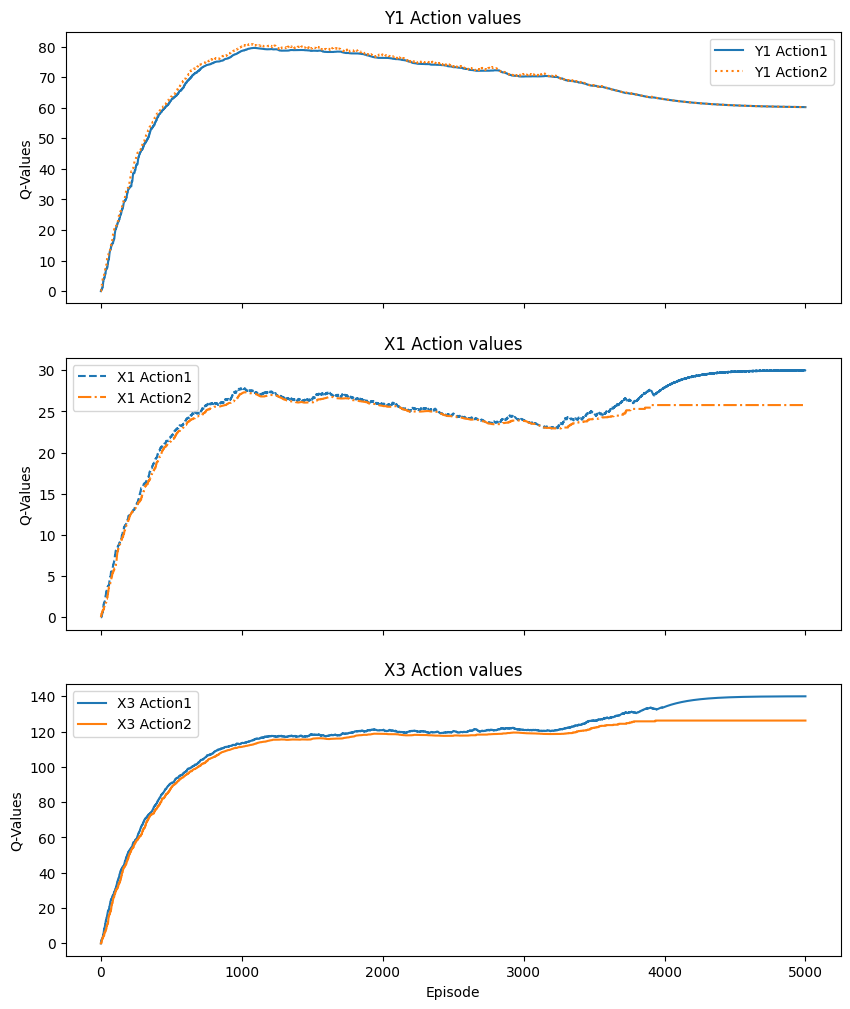

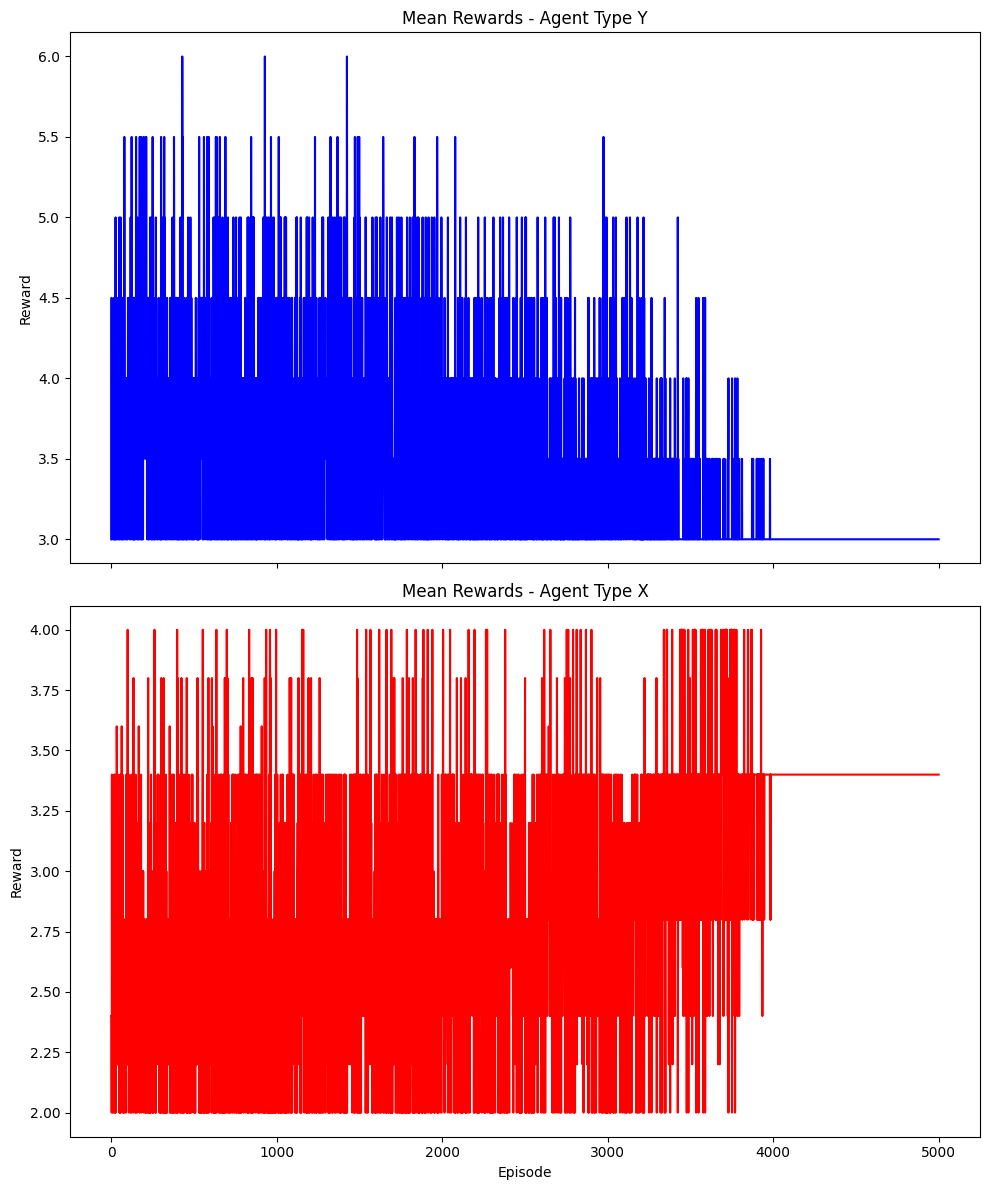

In [14]:
simulate1(5000)

### Interpretation

Given a learning rate of `alpha=0.1` agent `Y` sruggles to develop an optimal strategy. This happens because of its position in the adjacency graph and its inability to register the actions of its opponents. In the first group of graphs, we can clearly see how agent `Y1` fails to converge to a preference and does not to develop to an optimal strategy.

On the other hand, agents of type `X`, with the same leaerning rate, start to develop their optimal strategies around episode 4000. This becomes, somewhat, more evident when their graphs for `Q-table` values start to flatten. This flattening begins to happen when the term: $r+\gamma maxQ(s',a')−Q(s,a)$ begins to equal to zero. The term shows the error of the predictions the agents make in their moves. Once, it begins to flatten, current reward minus the discounted future reward become zero, thus leading to a stable value of just the current `Q-table` value.

The average cumulative reward graph shows how agents of type `X` have a higher reward than `Y1`.

---

# Scenario 2

## Environment implementation

In [15]:
class environment2():
    def __init__(self):
        # [[(Row_Payoff, Col_Payoff), ...], ...]
        self.payoff_matrix = [
            [(1, 2), (1, 1)],
            [(1,1), (2,1)]
        ]

      # Define types: X (Column players) and Y (Row players)
        self.agent_types = {
            "X1": "X", "X2": "X", "X3": "X", "X4": "X", "X5": "X",
            "Y1": "Y", "Y2": "Y"
        }

        # Define the djacency graph edges
        self.graph = {
            "X1": ["Y1"],
            "X2": ["Y2"],
            "Y1": ["X1", "X3", "X4"],
            "Y2": ["X2", "X3", "X5"],
            "X3": ["Y1", "Y2", "X4", "X5"],
            "X4": ["Y1", "X3"],
            "X5": ["Y2", "X3"]
        }

        # Epsilon decay parameters

    def reset(self):
        pass

    def step(self, action_matrix):
        """
        Distributes rewards.
        action_matrix = {agent_name: agent_action}
        """

        rewards = {name: 0 for name in self.graph.keys()}

        # Traverse each agent in the graph
        for each_agent in self.graph.keys():
            # Traverse each opponents and calculate rewards
            for each_opponent in self.graph[each_agent]:
                # Extract actions
                act_agent = action_matrix[each_agent] - 1
                act_opp = action_matrix[each_opponent] - 1

                # Extract row column combo from payoff matrix
                if "Y" in each_agent:
                    row_idx, col_idx = act_agent, act_opp

                elif "Y" in each_opponent:
                    row_idx, col_idx = act_opp, act_agent

                else:
                    # Same pair of agents: X vs X
                    row_idx, col_idx = act_agent, act_opp

                # Extract payoff block
                payoff_block = self.payoff_matrix[row_idx][col_idx]

                if "Y" in each_agent:
                    rewards[each_agent] += payoff_block[0]
                else:
                    rewards[each_agent] += payoff_block[1]

        return rewards

## Agent implementation

In [16]:

class QLearningAgent2():
    def __init__(self, agent_name, agent_type, actions=[1, 2], epsilon_init=1.0, epsilon_threshold=0.0, epsilon_decay=0.01, alpha=0.01, gamma=0.95):

        self.name = agent_name
        self.type = agent_type # "X" or "Y"
        self.action_space = actions

        # Q-table init - We have dynamic nof opponents here
        self.q_table = {}

        # Hyperparams
        self.epsilon = epsilon_init
        self.epsilon_threshold = epsilon_threshold
        self.epsilon_decay = epsilon_decay
        self.alpha = alpha
        self.gamma = gamma

        # Metric tracking
        self.reward_history = []
        self.action_value_history = {1: [], 2: []}

    def _get_q_values_for_state(self, state):
        """ Creates an entry if this neighbor combo is new """

        if state not in self.q_table:
            # Each action (1 and 2) starts at 0.0
            self.q_table[state] = {action: 0.0 for action in self.action_space}
        return self.q_table[state]

    def action(self, state):
        if np.random.rand() < self.epsilon:
            chosen_action = np.random.choice(self.action_space)
        else:
            # Fetch from dynamic state - opponent action
            state_q_values = self._get_q_values_for_state(state)
            max_val = max(state_q_values.values())
            best_action = [a for a, v in state_q_values.items() if v == max_val]
            chosen_action = np.random.choice(best_action)

        return chosen_action

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_threshold:
            self.epsilon -= self.epsilon_decay

    def update_q_values(self, current_state, action, reward, next_state):
        """
        Update Q-table values for agent.
        INPUTS:
            - current_state: neighbor's action @ t-1
            - next_state: neighbor's action @ t
        """
        # 1. Get current Q-value for the (state, action) pair
        current_q = self._get_q_values_for_state(current_state)[action]

        # 2. Look ahead: find max possible Q in next state
        next_state_qs = self._get_q_values_for_state(next_state)
        max_next_q = max(next_state_qs.values())

        # 3. Standard Q-learning formula (Bellman Equation) with state
        # Q(s,a) = Q(s,a) + alpha * [reward + gamma * max(Q(s',a')) - Q(s,a)]
        td_target = reward + (self.gamma * max_next_q)
        self.q_table[current_state][action] += self.alpha * (td_target - current_q)

## Simulation implementation

In [17]:
def simulate2(total_episodes):

    # Init metrics
    # Init value tracking
    q_table_values = {"Y1": [], "X1": [], "X3": []}
    mean_history_rewards = {"X": [], "Y": []}

    agent_types = {
        "X1": "X", "X2": "X", "X3": "X", "X4": "X", "X5": "X",
        "Y1": "Y", "Y2": "Y"
    }

    # Init enviromnet
    env = environment2()

    # Init agents
    # Define types: X (Column players) and Y (Row players)
    agents = dict()
    for name, agent_type in agent_types.items():
        agents[name] = QLearningAgent2(name, agent_type)

    # Initialize opponent moves - start with action 1
    prev_actions = {name: 1 for name in env.agent_types.keys()}

    # Reset env
    env.reset()

    # Simulation start
    for episode in range(total_episodes):
        current_actions = {}

        # Register actions
        for name, agent in agents.items():
            # Fetch agent neighbors
            neighbor_names = env.graph[name]
            # Register neighboring actions as state
            current_state = tuple(prev_actions[nb] for nb in neighbor_names)
            # Register agent action
            current_actions[name] = agent.action(current_state)

        # Step the environment
        rewards = env.step(current_actions)

        # Update Q-values for each agent
        for name, agent in agents.items():
            neighbor_names = env.graph[name]
            # The state we WERE in (at the start of this episode)
            old_state = tuple(prev_actions[nb] for nb in neighbor_names)
            # The state we ARE IN NOW (based on the actions just taken)
            new_state = tuple(current_actions[nb] for nb in neighbor_names)

            # Link State -> Action -> Reward -> Next State
            agent.update_q_values(old_state, current_actions[name], rewards[name], new_state)

        # Register rewards
        x_rewards = [rewards[agent] for agent in rewards if "X" in agent]
        y_rewards = [rewards[agent] for agent in rewards if "Y" in agent]
        mean_history_rewards["X"].append(np.mean(x_rewards))
        mean_history_rewards["Y"].append(np.mean(y_rewards))

        # Register Q-values
        for agent_name in q_table_values.keys():
            # Fetch neighbors
            ref_state = tuple(1 for _ in env.graph[agent_name])
            state_q_vals = agents[agent_name]._get_q_values_for_state(ref_state)
            q_table_values[agent_name].append(dict(state_q_vals))

        # Current actions become previous
        prev_actions = current_actions.copy()

        # Decay epsilon
        if (episode > 0) and (episode % 40 == 0):
            for agent in agents.values():
                agent.decay_epsilon()

    # Plot q-values for Y1,X1,X3
    # For each agent, we need 2 datapoints for the actions
    # Y1
    y1_a1 = [entry[1] for entry in q_table_values["Y1"]]
    y1_a2 = [entry[2] for entry in q_table_values["Y1"]]

    #X1
    x1_a1 = [entry[1] for entry in q_table_values["X1"]]
    x1_a2 = [entry[2] for entry in q_table_values["X1"]]

    #X3
    x3_a1 = [entry[1] for entry in q_table_values["X3"]]
    x3_a2 = [entry[2] for entry in q_table_values["X3"]]

    fig1, axs1 = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    # Y1 Plot
    axs1[0].plot(y1_a1, label="Action 1")
    axs1[0].plot(y1_a2, label="Action 2", linestyle="--")
    axs1[0].set_title("Y1 Action Values")
    axs1[0].set(ylabel="Q-Values")
    axs1[0].legend()

    # X1 Plot
    axs1[1].plot(x1_a1, label="Action 1")
    axs1[1].plot(x1_a2, label="Action 2", linestyle="--")
    axs1[1].set_title("X1 Action Values")
    axs1[1].set(ylabel="Q-Values")
    axs1[1].legend()

    # X3 Plot
    axs1[2].plot(x3_a1, label="Action 1")
    axs1[2].plot(x3_a2, label="Action 2", linestyle="--")
    axs1[2].set_title("X3 Action Values")
    axs1[2].set_xlabel("Episode")
    axs1[2].set(ylabel="Q-Values")
    axs1[2].legend()

    # plt.tight_layout()
    # plt.savefig("scenario2_action_values.png")

    #
    # # Plotting - mean rewards for 2 agent types
    fig2, (ax_y, ax_x) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

    ax_y.plot(mean_history_rewards["Y"], color="blue", label="Type Y")
    ax_y.set_title("Mean Rewards - Agent Type Y")
    ax_y.set_ylabel("Reward")

    ax_x.plot(mean_history_rewards["X"], color="red", label="Type X")
    ax_x.set_title("Mean Rewards - Agent Type X")
    ax_x.set_ylabel("Reward")
    ax_x.set_xlabel("Episode")

    plt.tight_layout()
    # plt.savefig("scenario2_average_rewards.png")
    # plt.close(fig2)

    plt.show(fig1)
    plt.show(fig2)

## Simulation results

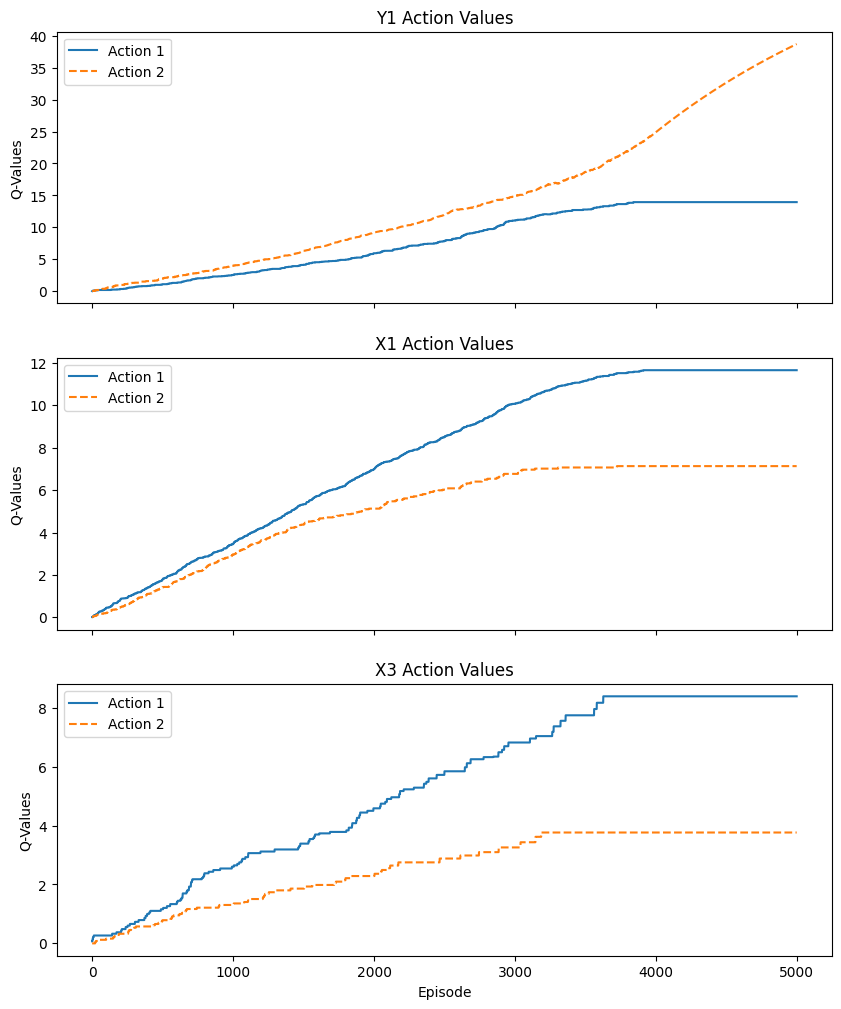

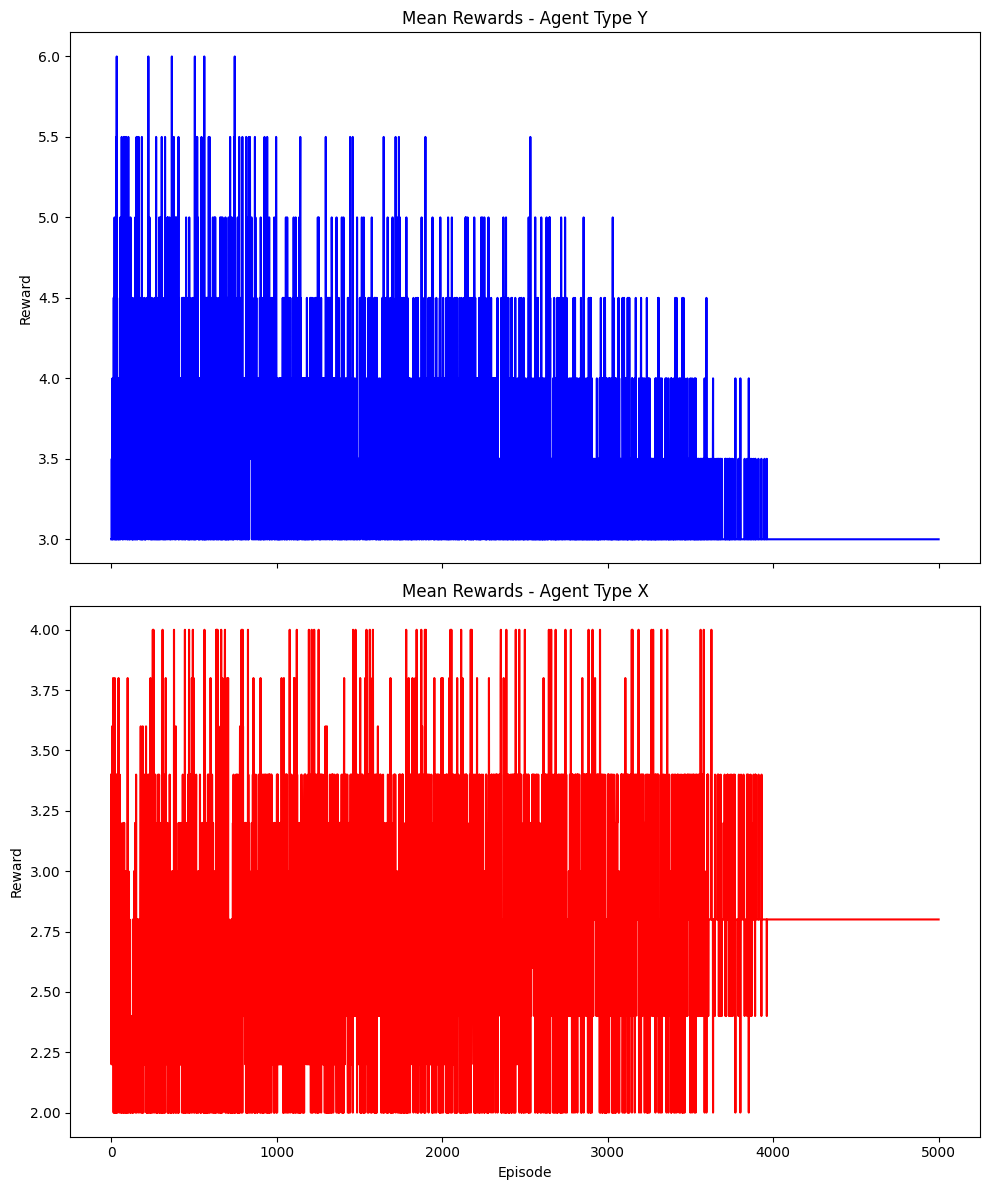

In [19]:
simulate2(5000)

## Interpretation

In Scenario 2, Agent `Y1` develops a clear preference for `Action 2` and its neighbors, `X1` and `X3`, have converged to play `Action 1` as their optimal strategies.

The `Q-table` graphs in scenario 2 show a much clear divergence between the action preferences for all the agents, compared to scenario 1. The `Q-values` of agent `Y1` are much higher because of its competing position in the graph. Each time it plays against 3 `X`-type agents, and by winning, its `Q-values` increase much faster than for others.

Moreover, we can see that the curve for `Action 2` is not flat. This shows that its temporal difference error is still positive and its update function keep returning higher values compared to the ones stored in its `Q-table`. `Y1` requires a higher number of episodes to achieve a full convergence.

The mean reward converges to a stable number after 4000 laps where the agents start exploiting their optimal strategies. Agent `Y1` shows a constant winning against its opponents.

# References

- https://stats.stackexchange.com/questions/206944/how-do-i-know-when-a-q-learning-algorithm-converges